In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_excel('flight_price_training_data.xlsx')

In [4]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [105]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [107]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [108]:
df.dropna(inplace=True)

In [109]:
data=df.copy()

In [110]:
def change_into_datetime(column):
    data[column]=pd.to_datetime(data[column])

In [111]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [112]:
for feature in ['Date_of_Journey','Dep_Time','Arrival_Time']:
    change_into_datetime(feature)

In [113]:
data['Journey_day']=data['Date_of_Journey'].dt.day

In [114]:
data['Journey_month']=data['Date_of_Journey'].dt.month

In [115]:
data['Journey_year']=data['Date_of_Journey'].dt.year

In [116]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-12-27 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-12-27 05:50:00,2025-12-27 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-12-27 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-12-27 18:05:00,2025-12-27 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-12-27 16:50:00,2025-12-27 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019


In [117]:
def extract_hour_minute(column):
    data[column+'_hour']=data[column].dt.hour
    data[column+'_minute']=data[column].dt.minute

In [118]:
extract_hour_minute('Dep_Time')
extract_hour_minute('Arrival_Time')

In [119]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute'],
      dtype='object')

In [120]:
columns_to_drop=['Date_of_Journey','Dep_Time','Arrival_Time']

In [121]:
data.drop(columns_to_drop,axis=1,inplace=True)

In [122]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [123]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute'],
      dtype='object')

In [124]:
def flight_dep_time(x):
    if (x>=0) & (x<6):
        return 'Early_Morning'
    elif (x>=6) & (x<12):
        return 'Morning'
    elif (x>=12) & (x<16):
        return 'Afternoon'
    elif (x>=16) & (x<20):
        return 'Evening'
    else:
        return 'Night'


<Axes: xlabel='Dep_Time_hour'>

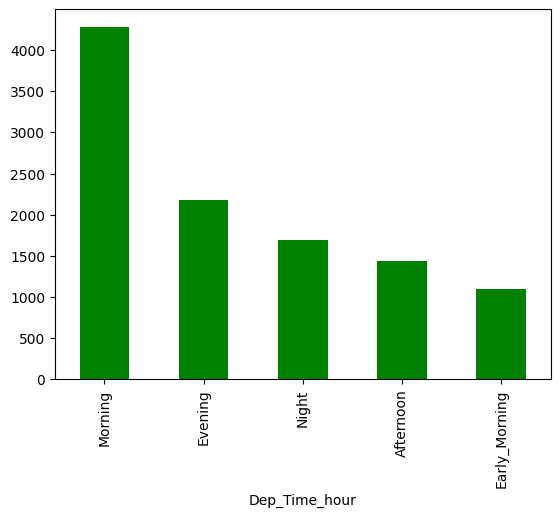

In [125]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind='bar', color='green')

In [126]:
def preprocess_duration(x):
    if 'h' not in x:
        x='0h '+x
    if 'm' not in x:
        x=x+' 0m'
    return x

In [127]:
data['Duration']=data['Duration'].apply(preprocess_duration)

In [128]:
int('2h 50m'.split(' ')[0][0:-1])

2

In [129]:
data['Duration_hours']=data['Duration'].apply(lambda x:int(x.split(' ')[0][0:-1]))
data['Duration_mins']=data['Duration'].apply(lambda x:int(x.split(' ')[1][0:-1]))

In [130]:
data['Duration_total_mins']=data['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Airline              10682 non-null  object
 1   Source               10682 non-null  object
 2   Destination          10682 non-null  object
 3   Route                10682 non-null  object
 4   Duration             10682 non-null  object
 5   Total_Stops          10682 non-null  object
 6   Additional_Info      10682 non-null  object
 7   Price                10682 non-null  int64 
 8   Journey_day          10682 non-null  int32 
 9   Journey_month        10682 non-null  int32 
 10  Journey_year         10682 non-null  int32 
 11  Dep_Time_hour        10682 non-null  int32 
 12  Dep_Time_minute      10682 non-null  int32 
 13  Arrival_Time_hour    10682 non-null  int32 
 14  Arrival_Time_minute  10682 non-null  int32 
 15  Duration_hours       10682 non-null  int64 
 16  Duration_

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

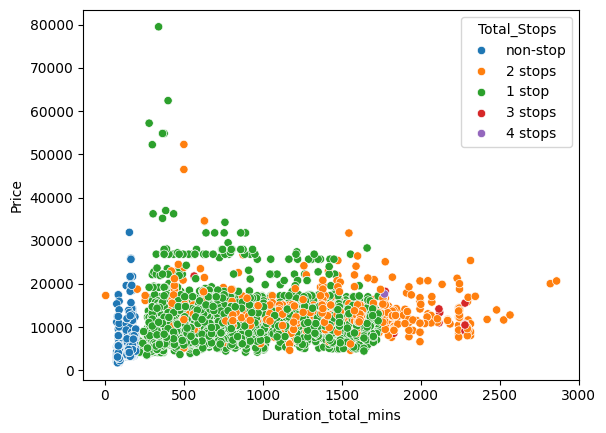

In [132]:
sns.scatterplot(x=data['Duration_total_mins'], y=data['Price'], hue=data['Total_Stops'])

<Axes: xlabel='Airline'>

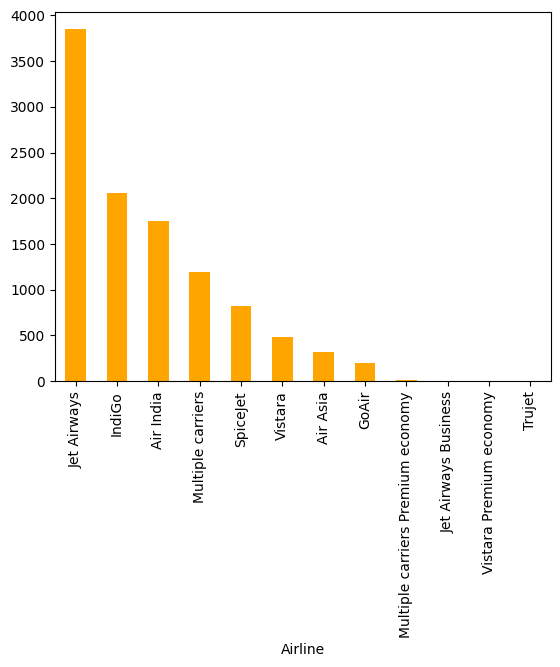

In [133]:
data['Airline'].value_counts().plot(kind='bar', color='orange')

In [134]:
data['Airline'].value_counts()


Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [135]:
data['Airline']=='Jet Airways'

0        False
1        False
2         True
3        False
4        False
         ...  
10678    False
10679    False
10680     True
10681    False
10682    False
Name: Airline, Length: 10682, dtype: bool

In [136]:
data[data['Airline']=='Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
BOM → HYD                207
DEL → JAI → BOM → COK    207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
DEL → CCU → BOM → COK      1
BOM → VNS → DEL → HYD      1
BOM → UDR → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → IDR → DEL → HYD      1
BOM → DED → DEL → HYD      1
dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'IndiGo'),
  Text(1, 0, 'Air India'),
  Text(2, 0, 'Jet Airways'),
  Text(3, 0, 'SpiceJet'),
  Text(4, 0, 'Multiple carriers'),
  Text(5, 0, 'GoAir'),
  Text(6, 0, 'Vistara'),
  Text(7, 0, 'Air Asia'),
  Text(8, 0, 'Vistara Premium economy'),
  Text(9, 0, 'Jet Airways Business'),
  Text(10, 0, 'Multiple carriers Premium economy'),
  Text(11, 0, 'Trujet')])

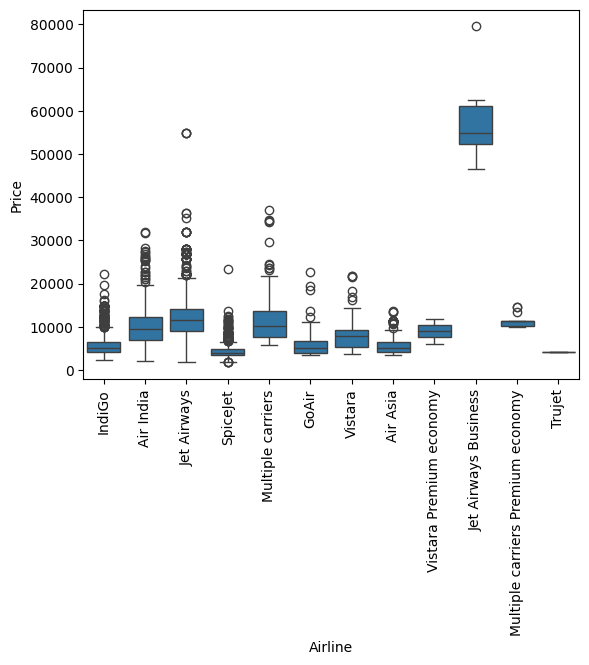

In [137]:
sns.boxplot(x=data['Airline'], y=data['Price'])
plt.xticks(rotation='vertical')

In [138]:
for col in data.columns:
    if data[col].dtype=='object':
        print(f"{col} : {data[col].nunique()}")

Airline : 12
Source : 5
Destination : 6
Route : 128
Duration : 368
Total_Stops : 5
Additional_Info : 10


In [139]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [140]:
data['Source'].apply(lambda x:1 if x=='Banglore' else 0)

0        1
1        0
2        0
3        0
4        1
        ..
10678    0
10679    0
10680    1
10681    1
10682    0
Name: Source, Length: 10682, dtype: int64

In [141]:
for subcategory in data['Source'].unique():
    data['Source_'+subcategory]=data['Source'].apply(lambda x:1 if x==subcategory else 0)

In [142]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,...,1,10,2,50,170,1,0,0,0,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,...,4,25,19,0,1140,0,0,1,0,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,...,23,30,5,25,325,0,1,0,0,0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,...,21,35,4,45,285,1,0,0,0,0


<Axes: xlabel='Airline'>

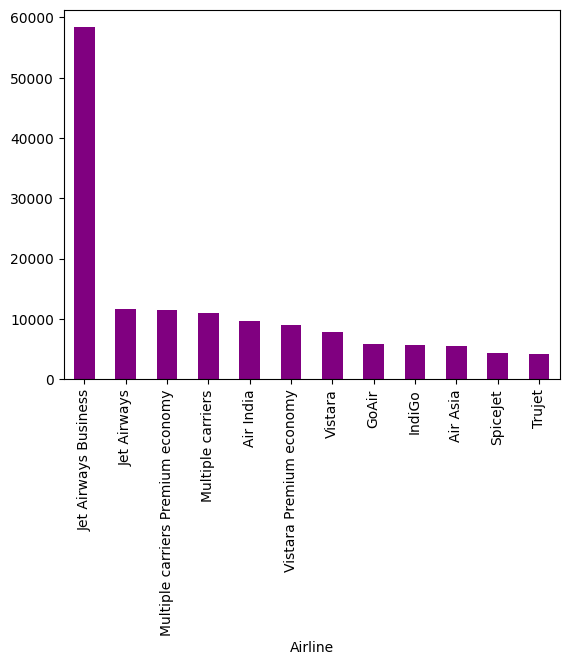

In [143]:
data.groupby(['Airline'])['Price'].mean().sort_values(ascending=False).plot(kind='bar', color='purple')

In [144]:
data.groupby(['Airline'])['Price'].mean().sort_values(ascending=False)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11643.923357
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9612.427756
Vistara Premium economy               8962.333333
Vistara                               7796.348643
GoAir                                 5861.056701
IndiGo                                5673.682903
Air Asia                              5590.260188
SpiceJet                              4338.284841
Trujet                                4140.000000
Name: Price, dtype: float64

In [145]:
airlines=data.groupby(['Airline'])['Price'].mean().sort_values().index

In [146]:
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [147]:
dict_airlines={}
for index, airline in enumerate(airlines):
    dict_airlines[airline]=index

In [148]:
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [149]:
data['Airline'] = data['Airline'].map(dict_airlines)

In [150]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,...,1,10,2,50,170,1,0,0,0,0
1,7,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,...,13,15,7,25,445,0,1,0,0,0
2,10,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,...,4,25,19,0,1140,0,0,1,0,0
3,3,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,...,23,30,5,25,325,0,1,0,0,0
4,3,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,...,21,35,4,45,285,1,0,0,0,0


In [151]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [152]:
data['Destination'].replace('New Delhi','Delhi',inplace=True)

In [153]:
dest=data.groupby(['Destination'])['Price'].mean().sort_values().index

In [154]:
dict_dest={}
for index, destination in enumerate(dest):
    dict_dest[destination]=index

In [155]:
data['Destination']=data['Destination'].map(dict_dest)

In [156]:
data['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [157]:
stop={'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}

In [158]:
data['Total_Stops']=data['Total_Stops'].map(stop)

In [159]:
data['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [160]:
data['Additional_Info'].value_counts()/len(data)*100

Additional_Info
No info                         78.112713
In-flight meal not included     18.554578
No check-in baggage included     2.995694
1 Long layover                   0.177869
Change airports                  0.065531
Business class                   0.037446
No Info                          0.028085
1 Short layover                  0.009362
Red-eye flight                   0.009362
2 Long layover                   0.009362
Name: count, dtype: float64

In [161]:
for var in data.columns:
    print(var)

Airline
Source
Destination
Route
Duration
Total_Stops
Additional_Info
Price
Journey_day
Journey_month
Journey_year
Dep_Time_hour
Dep_Time_minute
Arrival_Time_hour
Arrival_Time_minute
Duration_hours
Duration_mins
Duration_total_mins
Source_Banglore
Source_Kolkata
Source_Delhi
Source_Chennai
Source_Mumbai


In [162]:
data.drop(columns=['Additional_Info' , 'Duration_total_mins' , 'Source' , 'Journey_year'] , axis=1 , inplace=True)

In [163]:
data.drop(columns=['Route'] , axis=1 , inplace=True)

In [164]:
data.head()

,Airline,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,2h 50m,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,7h 25m,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,19h 0m,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,5h 25m,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,4h 45m,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [165]:
data.drop(columns=['Duration'] , axis=1 , inplace=True)

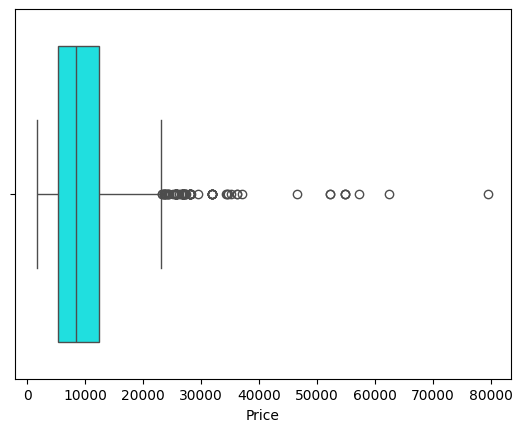

In [166]:
sns.boxplot(x=data['Price'],color='cyan')
plt.show()


In [167]:
q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

In [168]:
lower_bound

-5367.0

In [169]:
upper_bound

23017.0

In [170]:
data[(data['Price'] < lower_bound) | (data['Price'] > upper_bound)]['Price']


123      27430
396      36983
486      26890
510      26890
597      25139
         ...  
10353    24210
10364    57209
10383    26890
10439    31825
10511    26480
Name: Price, Length: 94, dtype: int64

In [171]:
data.head()

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [172]:
x=data.drop('Price',axis=1)

In [173]:
y=data['Price']

In [174]:
from sklearn.feature_selection import mutual_info_regression

In [175]:
imp= mutual_info_regression(x,y)

In [176]:
imp

array([1.31830763, 1.05855206, 0.78720256, 0.37406267, 0.6262536 ,
       0.93436761, 0.76040849, 1.1508072 , 0.90466398, 1.12189047,
       0.68039363, 0.38756795, 0.45879503, 0.53375854, 0.12384691,
       0.19459081])

In [177]:
imp_df=pd.DataFrame(imp,index=x.columns,columns=['Importance']).sort_values(by='Importance',ascending=False)

In [178]:
imp_df

,Importance
Airline,1.318308
Arrival_Time_hour,1.150807
Duration_hours,1.121890
Destination,1.058552
Dep_Time_hour,0.934368
Arrival_Time_minute,0.904664
Total_Stops,0.787203
Dep_Time_minute,0.760408
Duration_mins,0.680394
Journey_month,0.626254


<Axes: >

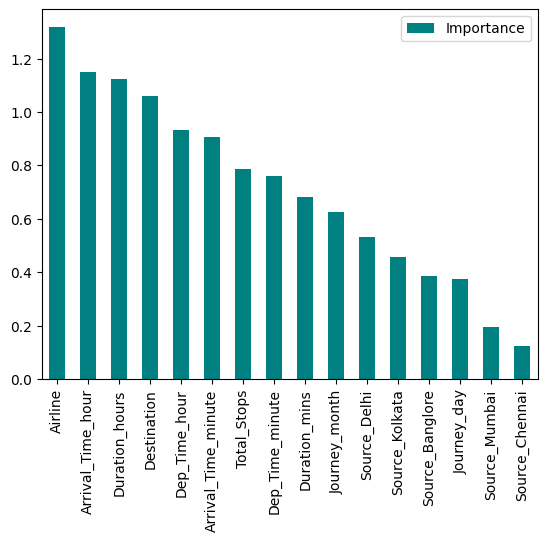

In [179]:
imp_df.plot(kind='bar', color='teal')

In [180]:
data.head()

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [181]:
from sklearn.model_selection import train_test_split

In [182]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [183]:
from sklearn.ensemble import RandomForestRegressor

In [184]:
ml_model=RandomForestRegressor()

In [185]:
ml_model.fit(x_train,y_train)

RandomForestRegressor()

In [186]:
y_pred=ml_model.predict(x_test)

In [187]:
for var in y_pred:
    print(var)

16859.04
5264.15
8817.47
3810.38
15199.038999999999
9969.715833333334
12508.725555555555
5697.607499999999
14221.718333333334
15150.988333333333
4174.36
9924.34
14172.865
3856.5400000000004
6486.8133333333335
3364.27
4229.29
6253.79
15295.23
8391.9
2173.264761904762
4822.28
5905.8125
5606.7
17286.287999999997
5279.615
3089.5
11902.301095238097
7408.67
5261.715
4413.81
13916.0225
4842.8116666666665
9593.2
4842.09
10172.945
8873.67
9881.2725
13301.269166666665
4920.197333333333
3853.5838095238087
4385.94
14389.56
7168.3116666666665
24017.78
4109.0
5507.24
5481.8533333333335
14680.25
11295.356999999996
8809.95
13086.3175
12696.666666666668
8554.995
16127.356500000002
8790.71
9080.62
8286.972666666667
14043.544
8308.018333333333
13224.339166666667
13400.58
4064.94
7350.435
16903.3
10360.926666666668
7994.0
11364.712166666668
15708.335666666666
12891.793499999998
5599.35
5127.49
6280.411999999999
4086.3300000000004
7675.65
6919.0225
3938.373567543568
8448.69
12364.08
10711.42
4726.138999999

In [188]:
from sklearn import metrics

In [189]:
metrics.r2_score(y_test,y_pred)

0.801111078083681

In [190]:
data['Predicted_Price']=ml_model.predict(x)

In [191]:
data.head()

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai,Predicted_Price
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0,5623.979
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0,8485.120
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0,13750.775
3,3,3,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0,6282.470
4,3,2,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0,11827.430


In [192]:
comparison = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': y_pred
})

comparison.head(10)


,Actual_Price,Predicted_Price
6075,16655,16859.040000
3544,4959,5264.150000
9291,9187,8817.470000
5032,3858,3810.380000
2483,12898,15199.039000
9894,10529,9969.715833
346,16079,12508.725556
6365,7229,5697.607500
7624,10844,14221.718333
3393,16289,15150.988333


In [193]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)


1174.7346074785899

In [194]:
import joblib

In [101]:
joblib.dump(ml_model,'flight_price_prediction_model.pkl')

['flight_price_prediction_model.pkl']